# Co-refinement of multiple contrast DMPC datasets in *refnx*

In [1]:
import os
# Set these FIRST before any other imports
os.environ["JAX_ENABLE_X64"] = "1"

In [2]:
# use matplotlib for plotting
%matplotlib inline
from pathlib import Path
import multiprocessing as mp
import warnings

from jax import config
config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="Numba will use object mode", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
from numpy.testing import assert_allclose
import pymc as pm
import arviz as az

import refnx, scipy

# the analysis module contains the curvefitting engine
from refnx.analysis import CurveFitter, Objective, Parameter, GlobalObjective, process_chain

# the reflect module contains functionality relevant to reflectometry
from refnx.reflect import SLD, ReflectModel, Structure, LipidLeaflet

# the ReflectDataset object will contain the data
from refnx.dataset import ReflectDataset

from refnx.reflect.extra import compile_global_objective, make_scipy_objective, to_pymc_model

In [3]:
pth = Path(os.getcwd()) / ".." / "refnx" / "analysis" / "tests"

data_d2o = ReflectDataset(pth / 'c_PLP0016596.dat')
data_d2o.name = "d2o"

data_hdmix = ReflectDataset(pth / 'c_PLP0016601.dat')
data_hdmix.name = "hdmix"

data_h2o = ReflectDataset(pth / 'c_PLP0016607.dat')
data_h2o.name = "h2o"

In [4]:
si = SLD(2.07 + 0j)
sio2 = SLD(3.47 + 0j)

# the following represent the solvent contrasts used in the experiment
d2o = SLD(6.36 + 0j)
h2o = SLD(-0.56 + 0j)
hdmix = SLD(2.07 + 0j)

# We want the `real` attribute parameter to vary in the analysis, and we want to apply
# uniform bounds. The `setp` method of a Parameter is a way of changing many aspects of
# Parameter behaviour at once.
d2o.real.setp(vary=True, bounds=(6.1, 6.36))
d2o.real.name='d2o SLD'

In [5]:
# Parameter for the area per molecule each DMPC molecule occupies at the surface. We
# use the same area per molecule for the inner and outer leaflets.
apm = Parameter(56, 'area per molecule', vary=True, bounds=(52, 65))

# the sum of scattering lengths for the lipid head and tail in Angstrom.
b_heads = Parameter(6.01e-4, 'b_heads')
b_tails = Parameter(-2.92e-4, 'b_tails')

# the volume occupied by the head and tail groups in cubic Angstrom.
v_heads = Parameter(319, 'v_heads')
v_tails = Parameter(782, 'v_tails')

# the head and tail group thicknesses.
inner_head_thickness = Parameter(9, 'inner_head_thickness', vary=True, bounds=(4, 11))
outer_head_thickness = Parameter(9, 'outer_head_thickness', vary=True, bounds=(4, 11))
tail_thickness = Parameter(14, 'tail_thickness', vary=True, bounds=(10, 17))

# finally construct a `LipidLeaflet` object for the inner and outer leaflets.
# Note that here the inner and outer leaflets use the same area per molecule,
# same tail thickness, etc, but this is not necessary if the inner and outer
# leaflets are different.
inner_leaflet = LipidLeaflet(apm,
                             b_heads, v_heads, inner_head_thickness,
                             b_tails, v_tails, tail_thickness,
                             3, 3)

# we reverse the monolayer for the outer leaflet because the tail groups face upwards
outer_leaflet = LipidLeaflet(apm,
                             b_heads, v_heads, outer_head_thickness,
                             b_tails, v_tails, tail_thickness,
                             3, 0, reverse_monolayer=True)

In [6]:
# Slab constructed from SLD object.
sio2_slab = sio2(15, 3)
sio2_slab.thick.setp(vary=True, bounds=(2, 30))
sio2_slab.thick.name = 'sio2 thickness'
sio2_slab.rough.setp(vary=True, bounds=(0, 7))
sio2_slab.rough.name = name='sio2 roughness'
sio2_slab.vfsolv.setp(0.1, vary=True, bounds=(0., 0.5))
sio2_slab.vfsolv.name = 'sio2 solvation'

solv_roughness = Parameter(3, 'bilayer/solvent roughness')
solv_roughness.setp(vary=True, bounds=(0, 5))

In [7]:
s_d2o = si | sio2_slab | inner_leaflet | outer_leaflet | d2o(0, solv_roughness)
s_hdmix = si | sio2_slab | inner_leaflet | outer_leaflet | hdmix(0, solv_roughness)
s_h2o = si | sio2_slab | inner_leaflet | outer_leaflet | h2o(0, solv_roughness)

In [8]:
model_d2o = ReflectModel(s_d2o)
model_hdmix = ReflectModel(s_hdmix)
model_h2o = ReflectModel(s_h2o)

model_d2o.scale.setp(vary=True, bounds=(0.9, 1.1))

model_d2o.bkg.setp(vary=True, bounds=(-5e-7, 1e-6))
model_hdmix.bkg.setp(vary=True, bounds=(-5e-7, 1e-6))
model_h2o.bkg.setp(vary=True, bounds=(-5e-7, 1e-6))

In [9]:
objective_d2o = Objective(model_d2o, data_d2o)
objective_hdmix = Objective(model_hdmix, data_hdmix)
objective_h2o = Objective(model_h2o, data_h2o)

global_objective = GlobalObjective([objective_d2o, objective_hdmix, objective_h2o])

In [10]:
fitter = CurveFitter(global_objective)
fitter.fit("differential_evolution");

-2746.624460662466: : 63it [00:10,  6.06it/s]/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/scipy/optimize/_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
-2746.624460662466: : 63it [00:10,  6.12it/s]


In [11]:
# check that the log-likelihood of the jax IR is the same as the global_objective
gco = compile_global_objective(global_objective)
logl, grad = gco.value_and_grad(np.array(global_objective.varying_parameters()))

assert_allclose(logl, global_objective.logl())

In [12]:
pm_model = to_pymc_model(global_objective)
with pm_model:
    idata = pm.sample(mp_ctx=mp.get_context("forkserver"))
    # idata = pm.sample(chains=4, cores=4, mp_ctx=mp.get_context("forkserver"))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p0, p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, p11, p12]


Output()

/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 393 seconds.


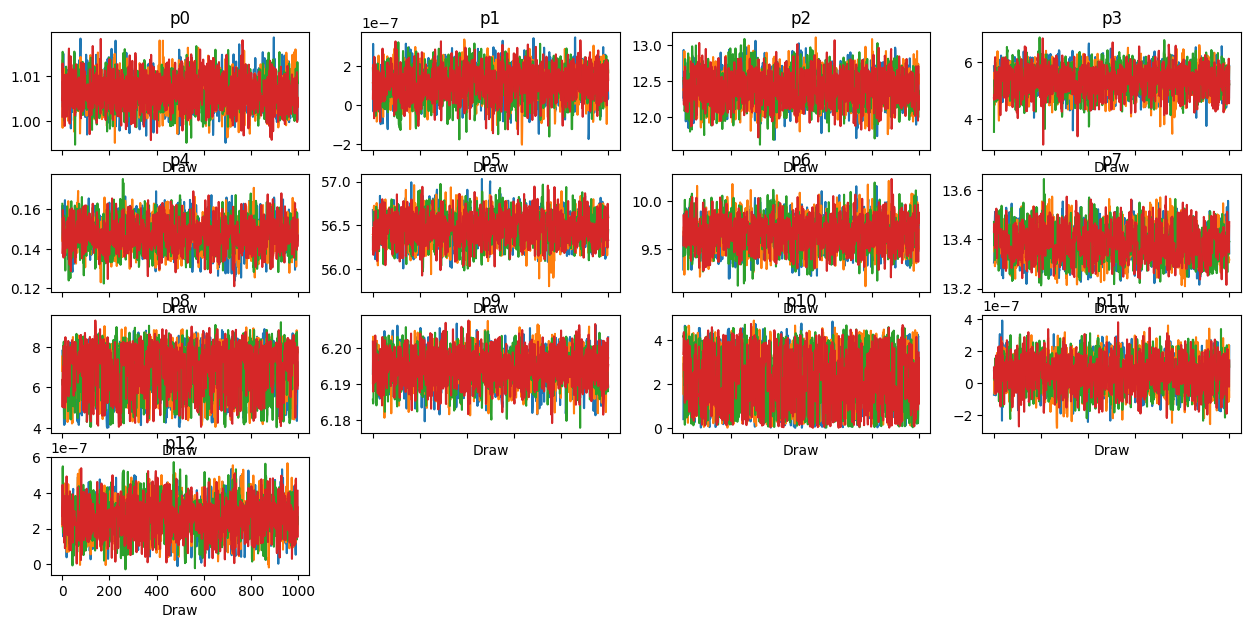

In [13]:
az.plot_trace(idata);

In [14]:
posterior_dataset = idata.posterior

summary = az.summary(idata)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p0,1.0066,0.00356,1,1,2870,2591,1.00,6.7e-05,4.7e-05
p1,1.04e-07,8e-08,-2.6e-08,2.3e-07,1917,2167,1.00,1.9e-09,1.3e-09
p2,12.39,0.226,12,13,1765,2330,1.00,0.0054,0.0037
p3,5.39,0.47,4.6,6.1,1906,2064,1.00,0.011,0.0081
p4,0.1471,0.0076,0.14,0.16,1843,2146,1.00,0.00018,0.00012
p5,56.468,0.166,56,57,1688,2087,1.00,0.0041,0.0029
p6,9.669,0.163,9.4,9.9,1799,2410,1.00,0.0038,0.0027
p7,13.387,0.068,13,13,1231,1738,1.00,0.0019,0.0012
p8,6.91,1.17,4.7,8.3,1093,1204,1.00,0.037,0.022
p9,6.1944,0.0045,6.2,6.2,2752,2311,1.00,8.7e-05,6.2e-05


In [15]:
# bring the pymc traces back into the Objective.
npars = len(global_objective.varying_parameters())
total_chain = [posterior_dataset[f'p{i}'].to_numpy() for i in range(npars)]
tc = np.r_[total_chain]
process_chain(global_objective, np.swapaxes(tc, 0, 2));

In [16]:
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:    'scale'    , value=1.00656 +/- 0.00356, bounds=[0.9, 1.1]>
<Parameter:     'bkg'     , value=1.05068e-07 +/- 8.09e-08, bounds=[-5e-07, 1e-06]>
<Parameter:'sio2 thickness', value=12.3855 +/- 0.229, bounds=[2.0, 30.0]>
<Parameter:'sio2 roughness', value=5.41602 +/- 0.469, bounds=[0.0, 7.0]>
<Parameter:'sio2 solvation', value=0.147169 +/- 0.00744, bounds=[0.0, 0.5]>
<Parameter:'area per molecule', value=56.4697 +/- 0.167, bounds=[52.0, 65.0]>
<Parameter:'inner_head_thickness', value=9.67004 +/- 0.16 , bounds=[4.0, 11.0]>
<Parameter:'tail_thickness', value=13.3858 +/- 0.0711, bounds=[10.0, 17.0]>
<Parameter:'outer_head_thickness', value=7.21554 +/- 1.26 , bounds=[4.0, 11.0]>
<Parameter:   'd2o SLD'   , value=6.19449 +/- 0.00445, bounds=[6.1, 6.36]>
<Parameter:'bilayer/solvent roughness', value=2.28495 +/- 1.51 , bounds=[0.0, 5.0]>
<Parameter:     'bkg'     , value=5.8

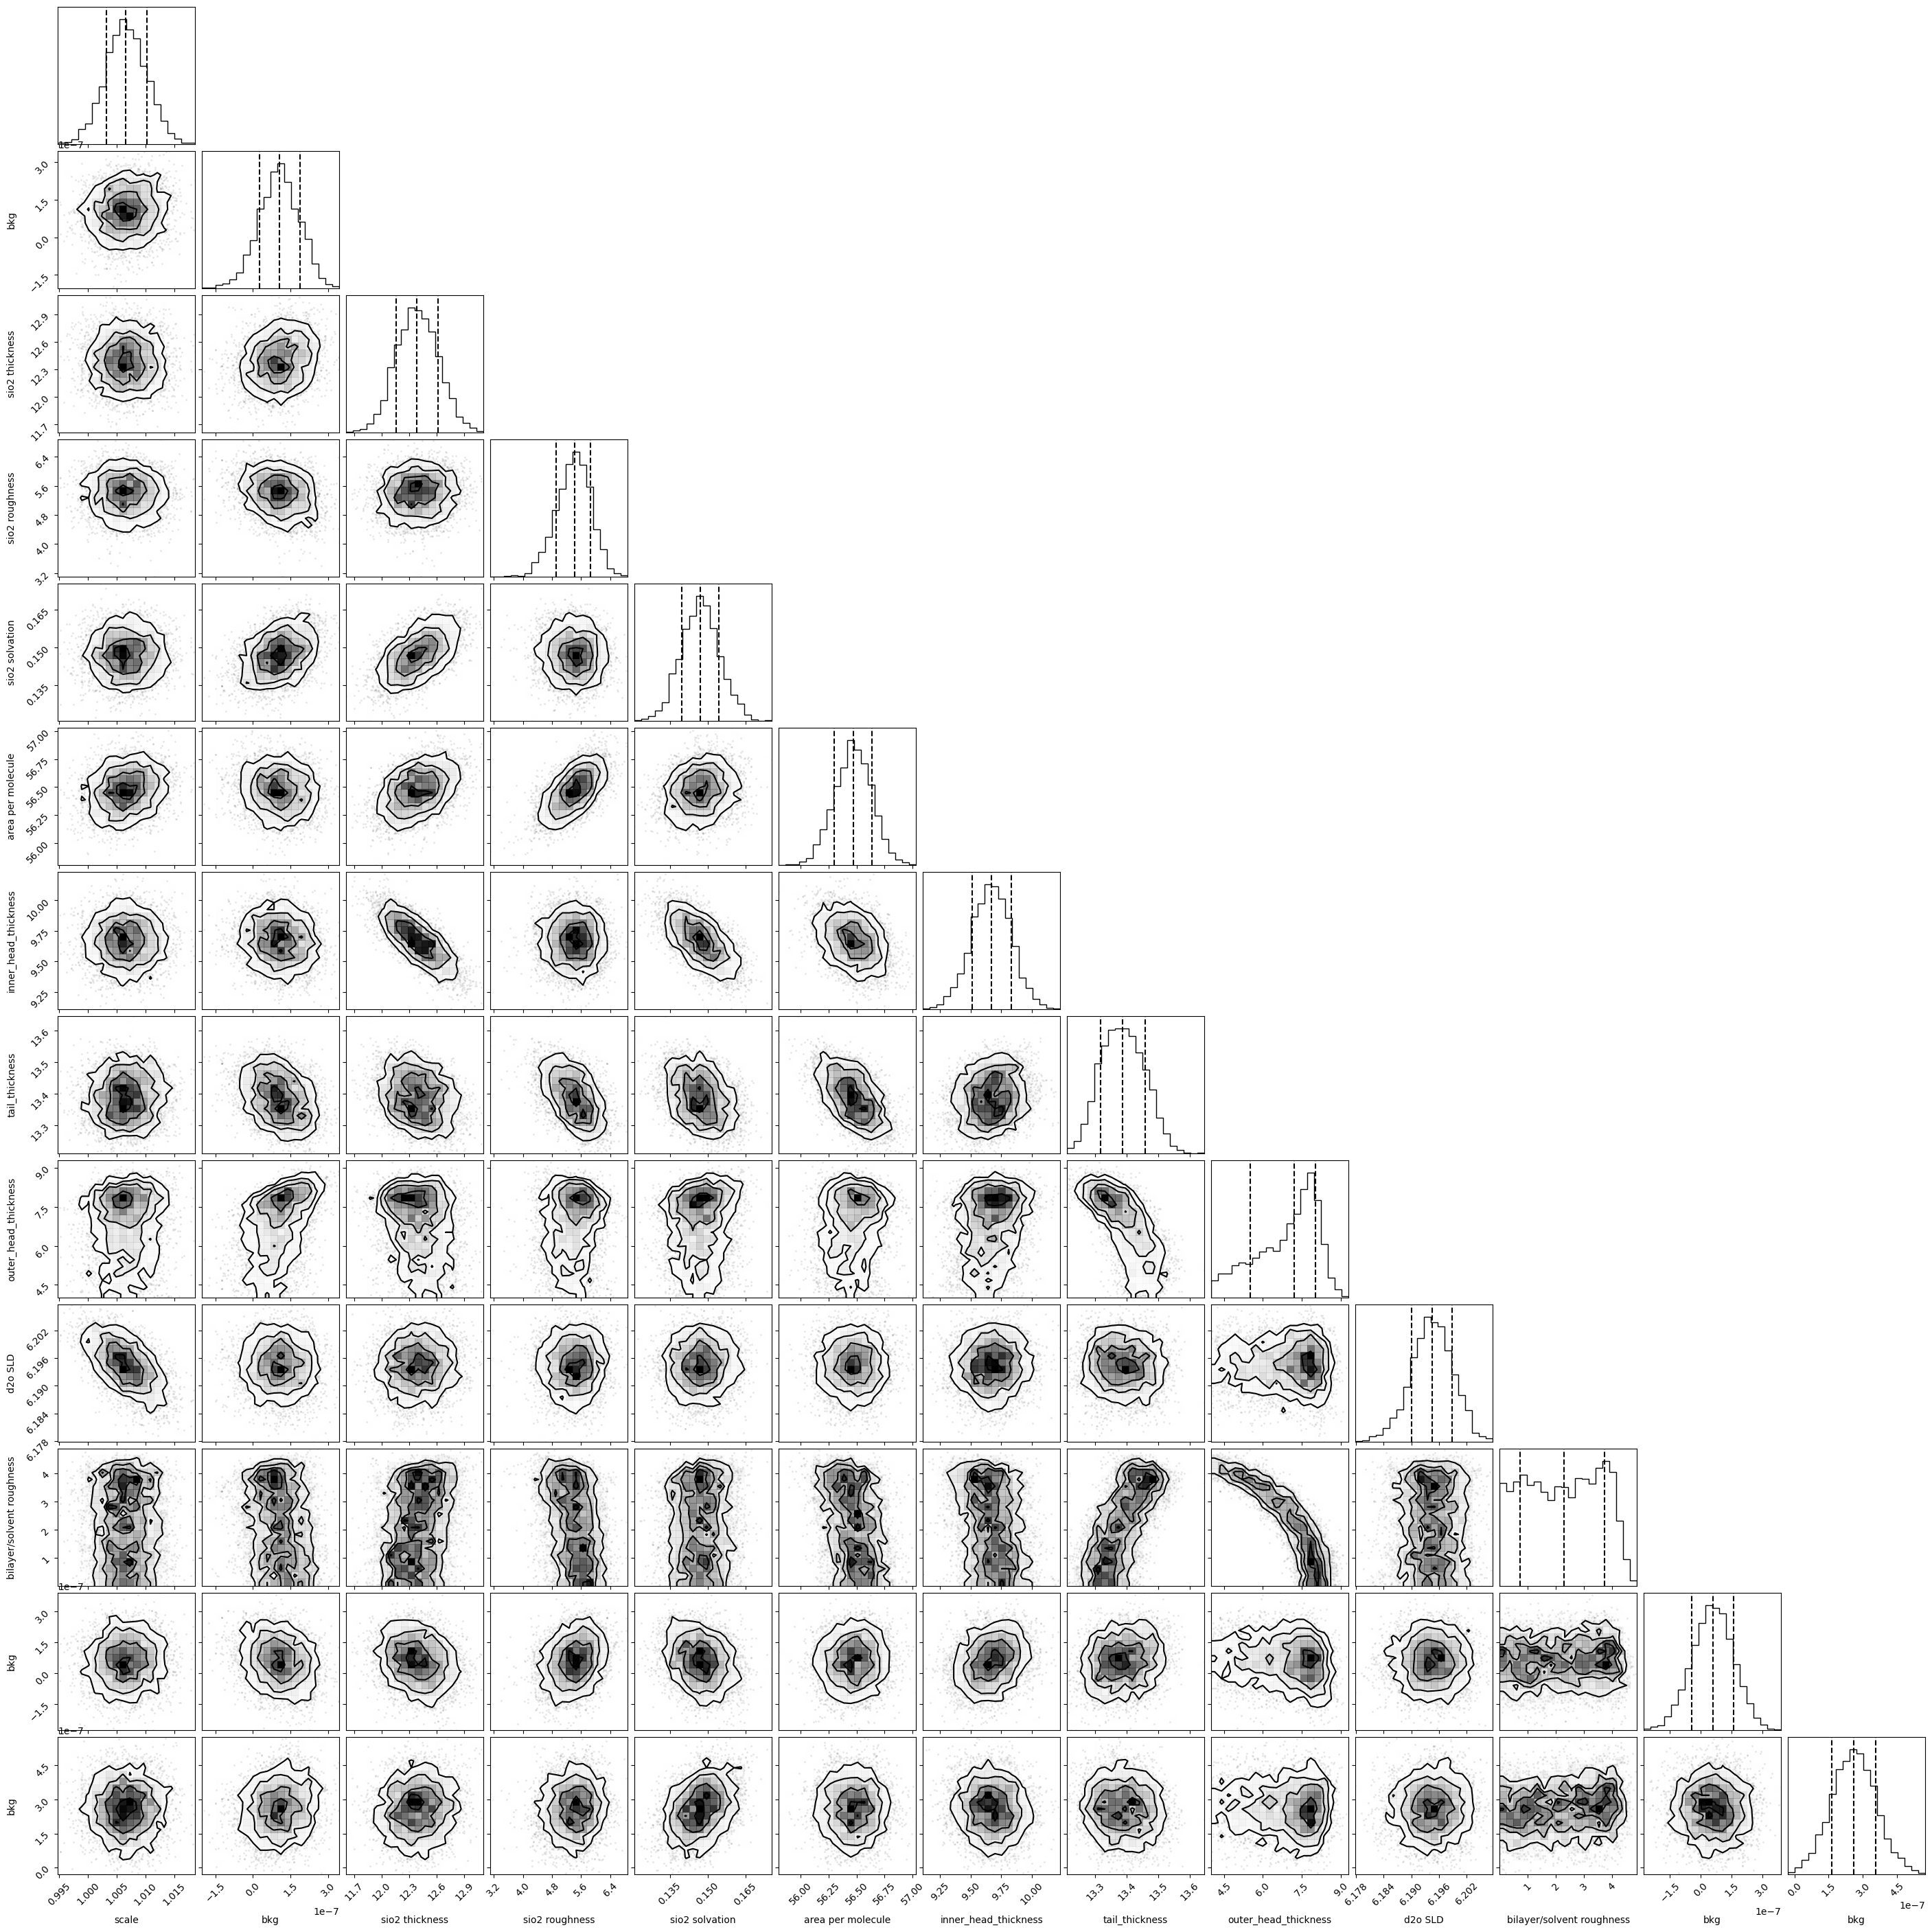

In [17]:
global_objective.corner();

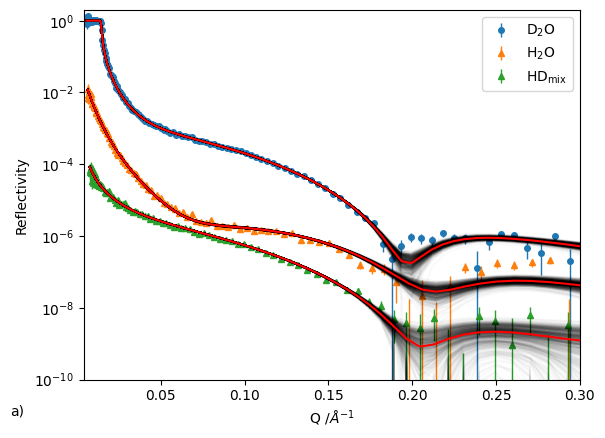

In [18]:
hdmix_mult = 0.01
h2o_mult = 0.1
# the data
plt.errorbar(data_d2o.x, data_d2o.y, data_d2o.y_err,
             label=r'$\mathregular{D_2O}$', ms=4, marker='o', lw=0, elinewidth=1)
plt.errorbar(data_h2o.x, data_h2o.y * h2o_mult, data_h2o.y_err * h2o_mult,
             label=r'$\mathregular{H_2O}$', ms=4, marker='^', lw=0, elinewidth=1)
plt.errorbar(data_hdmix.x, data_hdmix.y * hdmix_mult, data_hdmix.y_err * hdmix_mult,
             label=r'$\mathregular{HD_{mix}}$', ms=4, marker='^', lw=0, elinewidth=1)

# the median of the posterior
plt.plot(data_d2o.x, objective_d2o.generative(), color='r', zorder=20)
plt.plot(data_hdmix.x, objective_hdmix.generative() * hdmix_mult, color='r', zorder=20)
plt.plot(data_h2o.x, objective_h2o.generative() * h2o_mult, color='r', zorder=20)

# plot the spread of the fits for the different datasets
gen = global_objective.pgen(500)

save_pars = np.copy(global_objective.parameters)
for i in range(500):
    global_objective.setp(next(gen))

    plt.plot(data_d2o.x, objective_d2o.generative(),
             color='k', alpha=0.02, zorder=10)
    plt.plot(data_hdmix.x, objective_hdmix.generative() * hdmix_mult,
             color='k', alpha=0.02, zorder=10)
    plt.plot(data_h2o.x, objective_h2o.generative() * h2o_mult,
             color='k', alpha=0.02, zorder=10)

# put back the saved parameters
global_objective.setp(save_pars)

ax = plt.gca()
ax.text(-0.04, 1e-11, 'a)')
plt.legend()
plt.yscale('log')
plt.ylabel('Reflectivity')
plt.xlabel(r'Q /$\AA^{-1}$')
plt.ylim(1e-10, 2);
plt.xlim(0.004, 0.3);

In [19]:
print(global_objective)

________________________________________________________________________________


--Global Objective--
________________________________________________________________________________
Objective - 5965324912
Dataset = d2o
datapoints = 137
chi2 = 274.98176848525264
Weighted = True
Transform = None
________________________________________________________________________________
Parameters:       ''       
________________________________________________________________________________
Parameters: 'instrument parameters'
<Parameter:    'scale'    , value=1.00656 +/- 0.00356, bounds=[0.9, 1.1]>
<Parameter:     'bkg'     , value=1.05068e-07 +/- 8.09e-08, bounds=[-5e-07, 1e-06]>
<Parameter:'dq - resolution', value=5  (fixed) , bounds=[-inf, inf]>
<Parameter:  'q_offset'   , value=0  (fixed) , bounds=[-inf, inf]>
________________________________________________________________________________
Parameters: 'Structure - ' 
_________________________________________________________________________

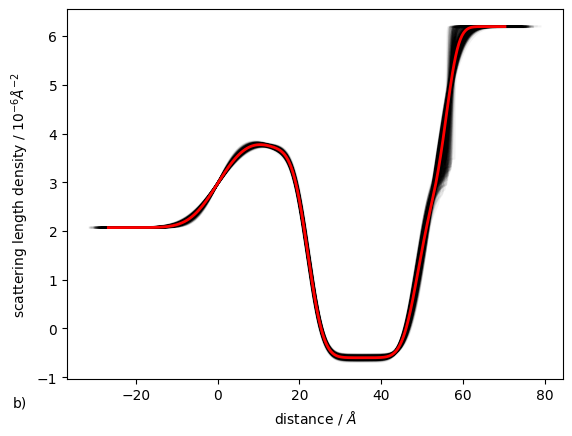

In [20]:
saved_params = np.array(objective_d2o.parameters)

z, median_sld = s_d2o.sld_profile()

for pvec in objective_d2o.pgen(ngen=500):
    objective_d2o.setp(pvec)
    zs, sld = s_d2o.sld_profile()
    plt.plot(zs, sld, color='k', alpha=0.05)

# put back saved_params
objective_d2o.setp(saved_params)

ax = plt.gca()
ax.text(-50, -1.6, 'b)')
plt.plot(z, median_sld, lw=2, color='r');
plt.ylabel(r'scattering length density / $10^{-6}\AA^{-2}$')
plt.xlabel(r'distance / $\AA$');